# SALES TREND AND CUSTOMER BEHAVIOUR IN AN ONLINE RETAIL STORE

In [1]:
import pandas as pd
pd.options.display.max_rows=1000
pd.options.display.max_columns=1000
df =pd.read_excel("Online Retail.xlsx")


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Data cleaning

### Filter out canceled orders (where InvoiceNo starts with 'C')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df1 = df[df["InvoiceNo"].str.contains("C")!=True] ##dataset that does not contaain cancelled order
df_can = df[df["InvoiceNo"].str.contains("C")==True]

In [6]:
df_can.count()

InvoiceNo      9288
StockCode      9288
Description    9288
Quantity       9288
InvoiceDate    9288
UnitPrice      9288
CustomerID     8905
Country        9288
dtype: int64

In [7]:
df_can ##canceled orders 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [8]:
df1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


### Handling misssing values

In [9]:
df1.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134697
Country             0
dtype: int64

In [10]:
df1=df1.dropna(subset=["CustomerID"])

In [11]:
df1.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [13]:
df1.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

# ANALYSIS

# Top performing products

#### Create a new column for TotalPrice by multiplying Quantity and UnitPrice

In [14]:
df1["Total_price"]=  df1['Quantity'] * df1['UnitPrice']

In [15]:
df1.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### The most occuring product by count

In [16]:
most_occuring_product=df1.groupby("StockCode")["InvoiceNo"].count().reset_index().sort_values(by="InvoiceNo",ascending=False)
most_occuring_product2=most_occuring_product.head(10)  ## the most occuring product by count
most_occuring_product2

,StockCode,InvoiceNo
3349,85123A,2035
1218,22423,1724
3343,85099B,1618
2602,84879,1408
2406,47566,1397
100,20725,1317
1500,22720,1159
102,20727,1105
3664,POST,1099
1963,23203,1098


#### TOP 10 PERFORMING PRODUCTS by quantity

In [17]:
Top_best_product=df1.groupby("StockCode").agg({"Total_price":"sum",
                             "Quantity":"sum"}).reset_index()

Top_best_product1=Top_best_product.sort_values(by="Quantity",ascending=False).head(10)   #TOP 10 PERFORMING PRODUCTS by quantity
Top_best_product1

,StockCode,Total_price,Quantity
2329,23843,168469.60,80995
1927,23166,81416.73,77916
2499,84077,13586.25,54415
1018,22197,37226.43,49183
3343,85099B,85220.78,46181
3349,85123A,100603.50,36782
2602,84879,56580.34,35362
353,21212,16394.53,33693
1849,23084,51346.20,27202
1282,22492,16039.24,26076


In [18]:
most_revenued_product=df1.groupby("StockCode").agg({"Total_price":"sum"}).reset_index()
most_revenued_product1=most_revenued_product.sort_values(by="Total_price",ascending=False).head(10) ## most sold products by Total price
most_revenued_product1

,StockCode,Total_price
2329,23843,168469.60
1218,22423,142592.95
3349,85123A,100603.50
3343,85099B,85220.78
1927,23166,81416.73
3664,POST,77803.96
2406,47566,68844.33
2602,84879,56580.34
3662,M,53779.93
1849,23084,51346.20


# Analysed to determine if the top products are sold because their unit price is high,medium,low

## Filtering Products with a highest cost price

In [19]:

# grouping the unit price into bins
df1["Bin_unitprice"]=pd.qcut(df1["UnitPrice"],q=3,labels=["low","medium","high"])

### product with a high price

In [20]:
high=df1[df1["Bin_unitprice"]=="high"]
# df1.groupby("Bin_unitprice").count()
high.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Total_price
count,108766.00000,108766,108766.000000,108766.000000,108766.000000
mean,5.60438,2011-07-07 16:10:34.753507328,7.465188,15242.444183,32.073184
min,1.00000,2010-12-01 08:26:00,2.960000,12347.000000,2.990000
25%,1.00000,2011-04-03 11:37:00,4.150000,13928.000000,8.950000
50%,2.00000,2011-07-27 09:32:00,4.950000,15044.000000,15.900000
75%,4.00000,2011-10-18 12:17:00,7.950000,16755.000000,25.000000
max,1412.00000,2011-12-09 12:50:00,8142.750000,18287.000000,38970.000000
std,20.64940,NaN,41.936949,1707.958088,159.320148


### The most occuring products that has a higher unit cost

In [21]:
hig_most_occuring=high.groupby("StockCode")["InvoiceNo"].count().reset_index().sort_values(by="InvoiceNo",ascending=False)
hig_most_occuring2=hig_most_occuring.head(10)## the most occuring products that has a higher unit cost

#### Merge to know the Most occuring(by frequency) products that has a high unit price and also exist as Most Occuring  products(in the whole dataset)

In [24]:
most_occuring_product2.merge(hig_most_occuring2,on="StockCode") # 4 product exist in the category

,StockCode,InvoiceNo_x,InvoiceNo_y
0,22423,1724,1723
1,47566,1397,1396
2,22720,1159,1159
3,POST,1099,1093


### Most sold  products (by quantity) that has a high unit price 

In [25]:
high_best_product=high.groupby("StockCode").agg({"Total_price":"sum",
                             "Quantity":"sum"}).reset_index()

high_best_product1=high_best_product.sort_values(by="Quantity",ascending=False).head(10)   #TOP 10 PERFORMING PRODUCTS
high_best_product1

,StockCode,Total_price,Quantity
1024,47566,68844.33,15291
451,22423,142592.95,12402
101,21137,39064.55,11406
1045,79321,46286.51,9650
720,22960,32415.17,8067
889,23298,36173.95,7785
593,22727,25925.20,7221
587,22720,33347.80,7020
1049,82484,34478.01,5921
877,23245,26625.68,5856


### Most sold products by quantity that are also exist as Top best products(in the whole data set)
* Since no product belong to this category that means products that has higher prices are not ordered mostly
* Advice; Offer product bundles at a slight discount.(Example: “Buy 3 and get one lesser product free")

In [26]:
Top_best_product1.merge(high_best_product1,on="StockCode") ## No product found

,StockCode,Total_price_x,Quantity_x,Total_price_y,Quantity_y


### Most sold products by total price that has a high unit price

In [27]:
high_most_revenued_product=high.groupby("StockCode").agg({"Total_price":"sum"}).reset_index()
high_most_revenued_product1=high_most_revenued_product.sort_values(by="Total_price",ascending=False).head(10)
high_most_revenued_product1


,StockCode,Total_price
451,22423,142592.95
1547,POST,77789.04
1024,47566,68844.33
1546,M,50442.45
498,22502,47364.20
1045,79321,46286.51
101,21137,39064.55
889,23298,36173.95
888,23284,35913.85
1049,82484,34478.01


#### Merge to know products sold with high unit price and also found as the most revenued product(in the whole dataset)

In [28]:
most_revenued_product1.merge(high_most_revenued_product1, on="StockCode") ## 4 products found

,StockCode,Total_price_x,Total_price_y
0,22423,142592.95,142592.95
1,POST,77803.96,77789.04
2,47566,68844.33,68844.33
3,M,53779.93,50442.45


In [29]:
df1

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,Bin_unitprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,medium
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,low
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,medium
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,high
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,high


#  Filtering Products with a low price

In [30]:
low=df1[df1["Bin_unitprice"]=="low"]
low.count()

InvoiceNo        140759
StockCode        140759
Description      140759
Quantity         140759
InvoiceDate      140759
UnitPrice        140759
CustomerID       140759
Country          140759
Total_price      140759
Bin_unitprice    140759
dtype: int64

#### Products that occured frequently and their unit prices are low(filtering the unit prices that are low)

In [31]:
low_most_occuring=low.groupby("StockCode")["InvoiceNo"].count().reset_index().sort_values(by="InvoiceNo",ascending=False)
low_most_occuring1=low_most_occuring.head(10)
low_most_occuring1

,StockCode,InvoiceNo
198,21212,1068
553,22197,1057
133,21034,952
926,22993,877
151,21080,753
66,20724,743
368,21790,726
1313,84991,691
437,21977,686
1305,84946,682


#### Merge to know Products that occured frequently with low unit prices and also found as the most occuring product(in the whole dataset)
* That means the 0 products found has a low unitprice

In [32]:
most_occuring_product2.merge(low_most_occuring1,on="StockCode") ## 0 product found

,StockCode,InvoiceNo_x,InvoiceNo_y


### Products that has the highest quantity and their unit prices are low(filter form the low dataset)

In [33]:
low_best_product=low.groupby("StockCode").agg({"Total_price":"sum",
                             "Quantity":"sum"}).reset_index()

low_best_product1=low_best_product.sort_values(by="Quantity",ascending=False).head(10)  
low_best_product1

,StockCode,Total_price,Quantity
983,23166,81416.73,77916
1258,84077,13586.25,54415
553,22197,36978.67,49031
198,21212,16394.53,33693
689,22492,16026.20,26068
764,22616,7266.71,25345
437,21977,11629.70,24264
36,17003,5980.05,22963
8,15036,16044.44,21876
418,21915,23587.29,20891


#### Merge to know Products that has the highest quantity with a low unit prices and also exist as the top best products by quantity(in the whole data set)

In [34]:
Top_best_product1.merge(low_best_product1,on="StockCode") ## 5 found products

,StockCode,Total_price_x,Quantity_x,Total_price_y,Quantity_y
0,23166,81416.73,77916,81416.73,77916
1,84077,13586.25,54415,13586.25,54415
2,22197,37226.43,49183,36978.67,49031
3,21212,16394.53,33693,16394.53,33693
4,22492,16039.24,26076,16026.20,26068


#### Products that has the highest sales and their unit prices are low(total sale)

In [35]:
low_most_revenued_product=low.groupby("StockCode").agg({"Total_price":"sum"}).reset_index()
low_most_revenued_product1=low_most_revenued_product.sort_values(by="Total_price",ascending=False).head(10)
low_most_revenued_product1

,StockCode,Total_price
983,23166,81416.73
553,22197,36978.67
418,21915,23587.29
547,22178,19804.95
1305,84946,18951.60
800,22693,17226.20
198,21212,16394.53
8,15036,16044.44
689,22492,16026.20
1258,84077,13586.25


#### Products that has the highest sales with a low unit prices and also exist as the most_revenued_product(Total_price)(in the whole dataset)

In [36]:
most_revenued_product1.merge(low_most_revenued_product1,on ="StockCode")## 1 found

,StockCode,Total_price_x,Total_price_y
0,23166,81416.73,81416.73


##  Filtering Product with medium price

In [37]:
medium=df1[df1["Bin_unitprice"]=="medium"]
medium.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Total_price
count,148399.000000,148399,148399.000000,148399.000000,148399.000000
mean,11.830221,2011-07-09 15:10:13.752788224,2.108437,15318.923066,23.422014
min,1.000000,2010-12-01 08:26:00,1.270000,12347.000000,1.450000
25%,2.000000,2011-04-05 13:42:00,1.650000,13985.000000,4.200000
50%,6.000000,2011-07-28 14:08:00,2.080000,15228.000000,13.520000
75%,12.000000,2011-10-20 10:34:00,2.550000,16813.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,2.950000,18287.000000,168469.600000
std,213.136472,NaN,0.508025,1710.983527,442.656084


#### Products that occured frequently and their unit prices are medium

In [38]:
medium_most_occuring=medium.groupby("StockCode")["InvoiceNo"].count().reset_index().sort_values(by="InvoiceNo",ascending=False)
medium_most_occuring1=medium_most_occuring.head(10)
medium_most_occuring1

,StockCode,InvoiceNo
1588,85123A,2017
1582,85099B,1613
1265,84879,1408
42,20725,1307
44,20727,1105
1007,23203,1098
611,22383,1080
1012,23209,1028
453,22086,1005
610,22382,1004


#### merge to know Products that occured frequently with medium unit prices and also found as the most occuring product(in the whole dataset)

In [40]:
most_occuring_product2.merge(medium_most_occuring1,on="StockCode")## 6 found

,StockCode,InvoiceNo_x,InvoiceNo_y
0,85123A,2035,2017
1,85099B,1618,1613
2,84879,1408,1408
3,20725,1317,1307
4,20727,1105,1105
5,23203,1098,1098


#### Products that are mostly ordered and their unit prices are medium(by quantity)

In [41]:
medium_best_product=medium.groupby("StockCode").agg({"Total_price":"sum",
                             "Quantity":"sum"}).reset_index()

medium_best_product1=medium_best_product.sort_values(by="Quantity",ascending=False).head(10)  
medium_best_product1

,StockCode,Total_price,Quantity
1155,23843,168469.60,80995
1582,85099B,85196.00,46175
1265,84879,56580.34,35362
1588,85123A,87268.60,32654
955,23084,50218.71,26929
614,22386,37285.46,20164
1007,23203,37684.38,19516
42,20725,28214.55,17867
1584,85099F,30631.81,16804
659,22469,27925.70,16514


#### Merge to know Products that has the highest quantity with a medium unit prices and also exist as the top best products by quantity(in the whole datasets)

In [42]:
Top_best_product1.merge(medium_best_product1,on="StockCode") ## 5 produts found

,StockCode,Total_price_x,Quantity_x,Total_price_y,Quantity_y
0,23843,168469.60,80995,168469.60,80995
1,85099B,85220.78,46181,85196.00,46175
2,85123A,100603.50,36782,87268.60,32654
3,84879,56580.34,35362,56580.34,35362
4,23084,51346.20,27202,50218.71,26929


#### Products that has the highest sales and their unit prices are medium (by total sale)

In [43]:
medium_most_revenued_product=medium.groupby("StockCode").agg({"Total_price":"sum"}).reset_index()
medium_most_revenued_product1=medium_most_revenued_product.sort_values(by="Total_price",ascending=False).head(10)
medium_most_revenued_product1

,StockCode,Total_price
1155,23843,168469.60
1588,85123A,87268.60
1582,85099B,85196.00
1265,84879,56580.34
955,23084,50218.71
453,22086,41751.80
1007,23203,37684.38
614,22386,37285.46
1584,85099F,30631.81
42,20725,28214.55


#### Merge to know Products that has the highest sales with a medium unit prices and also exist as the most_revenued_product(Total_price)(in the whole dataset)

In [44]:
most_revenued_product1.merge(medium_most_revenued_product1,on="StockCode")## 5 found

,StockCode,Total_price_x,Total_price_y
0,23843,168469.60,168469.60
1,85123A,100603.50,87268.60
2,85099B,85220.78,85196.00
3,84879,56580.34,56580.34
4,23084,51346.20,50218.71


## Final analysis For Products
### Unit price categories
* High Cost price 
* Low cost price    
* Medium cost price 
#### For the top performing products(by frequency of occurance). in which category or group(using the unit price to group) does each product(10) belong?
* High Cost price   :   4producs
* Low cost price    :  0 products
* Medium cost price :  6 product
  
  Here you can see that the most ocuring product ocur mostly becauce the prices are medium
 #### For the top best products(by quantity/order), in which category or group(using the unit price to group) does each product(10) belong? 
* High Cost price   :   0 products
* Low cost price    :  5 products
* Medium cost price :  5 product
  
  Since no product belong to the high cost price category that means products that have higher prices are not ordered in larger quantities but those with low and medium prices are ordered in larger quantities
  
  Advice; Offer product bundles at a slight discount.(Example: “Buy 3 and get one lesser product free")
#### For the top revenued product(products that generated much income), in which category or group(using the unit price to group) does each product(10) belong? 
* High Cost price   :   4producs
* Low cost price    :  1 products
* Medium cost price :  5product  
  
Although Products that have higher unit prices are not ordered in bulk but they generated much revenue, they should strategized on promoting the products with the higher price unit by either giving discounts for people that ordered in bulk or adsertiving the products more

# Customer purchase behavior


## Top customers by revenue.

In [45]:
df1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,Bin_unitprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,medium
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high


In [46]:
Top_customer=df1.groupby("CustomerID").agg({"Total_price":"sum",
                             "Quantity":"sum"}).reset_index()

#TOP 10 CUSTOMERS
Best_top_custo=Top_customer.sort_values(by="Total_price",ascending=False)
Best_top_custo.head(20)  

,CustomerID,Total_price,Quantity
1690,14646.0,280206.02,197491
4202,18102.0,259657.30,64124
3729,17450.0,194550.79,69993
3009,16446.0,168472.50,80997
1880,14911.0,143825.06,80515
55,12415.0,124914.53,77670
1334,14156.0,117379.63,57885
3772,17511.0,91062.38,64549
2703,16029.0,81024.84,40208
0,12346.0,77183.60,74215


#### checking if the top  customers buy repeatedly, orders rarely
It helps you analyze customer behavior, such as:

* How many customers are frequent buyers(loyal)?

* How many customers are rare buyers?

* Check if top customers are loyal customers, or rare buyers that bought a few times but in bulk

* Who are your most loyal customers?


#### Top customers by frequncy of patronage

In [47]:
customer_freq = df1.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()##For each customer, count the number of unique InvoiceNo entries.
# customer_freq.sort_values(by="InvoiceNo",ascending=False)
customer_freq.columns=["CustomerID","No_of_entries"]
bins=[0,5,248]
labels=["rarely","loyal"]
customer_freq["customerbehavior"]=pd.cut(customer_freq["No_of_entries"],bins=bins,labels=labels)
frequet_cust=customer_freq.sort_values(by="No_of_entries",ascending=False)
frequet_cust.head(20)

,CustomerID,No_of_entries,customerbehavior
326,12748.0,210,loyal
1880,14911.0,201,loyal
4011,17841.0,124,loyal
562,13089.0,97,loyal
1662,14606.0,93,loyal
2177,15311.0,91,loyal
481,12971.0,86,loyal
1690,14646.0,74,loyal
2703,16029.0,63,loyal
796,13408.0,62,loyal


In [48]:
customer_freq["customerbehavior"].value_counts() ## Count of the customer behaviour

customerbehavior
rarely    3467
loyal      872
Name: count, dtype: int64

#### Mergence of the dataframes (top customers by revenue + top customers by frequency of patronage)

In [49]:
## #### here checks if the best top customers by revenue are frequent buyers or rare buyers
top_rev_freq =   Best_top_custo.merge(frequet_cust) #14646.0	280206.02	197491
top_rev_freq.sort_values(by="Total_price",ascending=False).head(10) 


,CustomerID,Total_price,Quantity,No_of_entries,customerbehavior
0,14646.0,280206.02,197491,74,loyal
1,18102.0,259657.30,64124,60,loyal
2,17450.0,194550.79,69993,46,loyal
3,16446.0,168472.50,80997,2,rarely
4,14911.0,143825.06,80515,201,loyal
5,12415.0,124914.53,77670,21,loyal
6,14156.0,117379.63,57885,55,loyal
7,17511.0,91062.38,64549,31,loyal
8,16029.0,81024.84,40208,63,loyal
9,12346.0,77183.60,74215,1,rarely



From the analysis majority of the top customers are loyal buyers

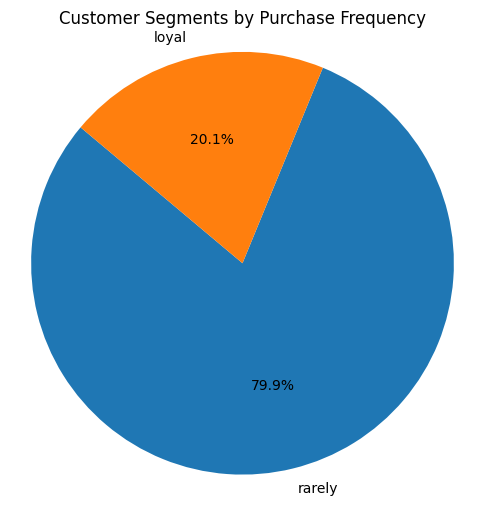

In [50]:
import matplotlib.pyplot as plt

buyer_counts = customer_freq['customerbehavior'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(buyer_counts, labels=buyer_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Customer Segments by Purchase Frequency')
plt.axis('equal')
plt.show()


## Analysis to  tells us how long ago each customer made their last purchase.
* It helps us know who is still active and who may have stopped buying (2 means they bought something 2 days ago,120 they haven’t bought in 4 months)

In [51]:
day_of_last_purchase = df1['InvoiceDate'].max() + pd.Timedelta(days=1)
day_of_last_purchase ##how many days ago the last purchase happened from today


Timestamp('2011-12-10 12:50:00')

In [52]:
customer_last_purchase = df1.groupby('CustomerID')['InvoiceDate'].max().reset_index()
customer_last_purchase.head(3) ##Group by Customer and Find Their Last Purchase Date(each customer)

,CustomerID,InvoiceDate
0,12346.0,2011-01-18 10:01:00
1,12347.0,2011-12-07 15:52:00
2,12348.0,2011-09-25 13:13:00


In [53]:
customer_last_purchase['Recency'] = (day_of_last_purchase - customer_last_purchase['InvoiceDate']).dt.days
## Subtract to Get the Number of Days Since Last Purchase for each customer

In [54]:
customer_last_purchase

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310
...,...,...,...
4334,18280.0,2011-03-07 09:52:00,278
4335,18281.0,2011-06-12 10:53:00,181
4336,18282.0,2011-12-02 11:43:00,8
4337,18283.0,2011-12-06 12:02:00,4


#### Mergence of DataFrames (Top customers by revenue & The last time of their purchase )
    This  is to check if the top customers,the number of days they made their last purchase 

In [55]:
top_rev_freq.merge(customer_last_purchase).sort_values(by="Total_price",ascending=False).head(10)

,CustomerID,Total_price,Quantity,No_of_entries,customerbehavior,InvoiceDate,Recency
0,14646.0,280206.02,197491,74,loyal,2011-12-08 12:12:00,2
1,18102.0,259657.30,64124,60,loyal,2011-12-09 11:50:00,1
2,17450.0,194550.79,69993,46,loyal,2011-12-01 13:29:00,8
3,16446.0,168472.50,80997,2,rarely,2011-12-09 09:15:00,1
4,14911.0,143825.06,80515,201,loyal,2011-12-08 15:54:00,1
5,12415.0,124914.53,77670,21,loyal,2011-11-15 14:22:00,24
6,14156.0,117379.63,57885,55,loyal,2011-11-30 10:54:00,10
7,17511.0,91062.38,64549,31,loyal,2011-12-07 10:12:00,3
8,16029.0,81024.84,40208,63,loyal,2011-11-01 10:27:00,39
9,12346.0,77183.60,74215,1,rarely,2011-01-18 10:01:00,326


## Final Advise on improving customer behaviour
* Create loyalty programs to reward repeated purchases 
* Offer exclusive deals to high spenders or upsell premium products by Offering bundle or bulk purchase discounts
* Send personalized re-engagement emails to recent/old buyers
* For customers that often buy a small number of items, recommend complementary products(cross-selling)
* Highlight items based on browsing/cart behavior (if available)

# TOTAL SALES BY COUNTY

In [56]:
df1['Country']
df_count=df1.groupby("Country")["Total_price"].sum().reset_index()

#SALES BY COUNTRY
top_county=df_count.sort_values(by="Total_price",ascending=False)
top_county.head()



,Country,Total_price
35,United Kingdom,7308391.554
23,Netherlands,285446.340
10,EIRE,265545.900
14,Germany,228867.140
13,France,209024.050


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'Belgium'),
  Text(9, 0, 'Sweden')])

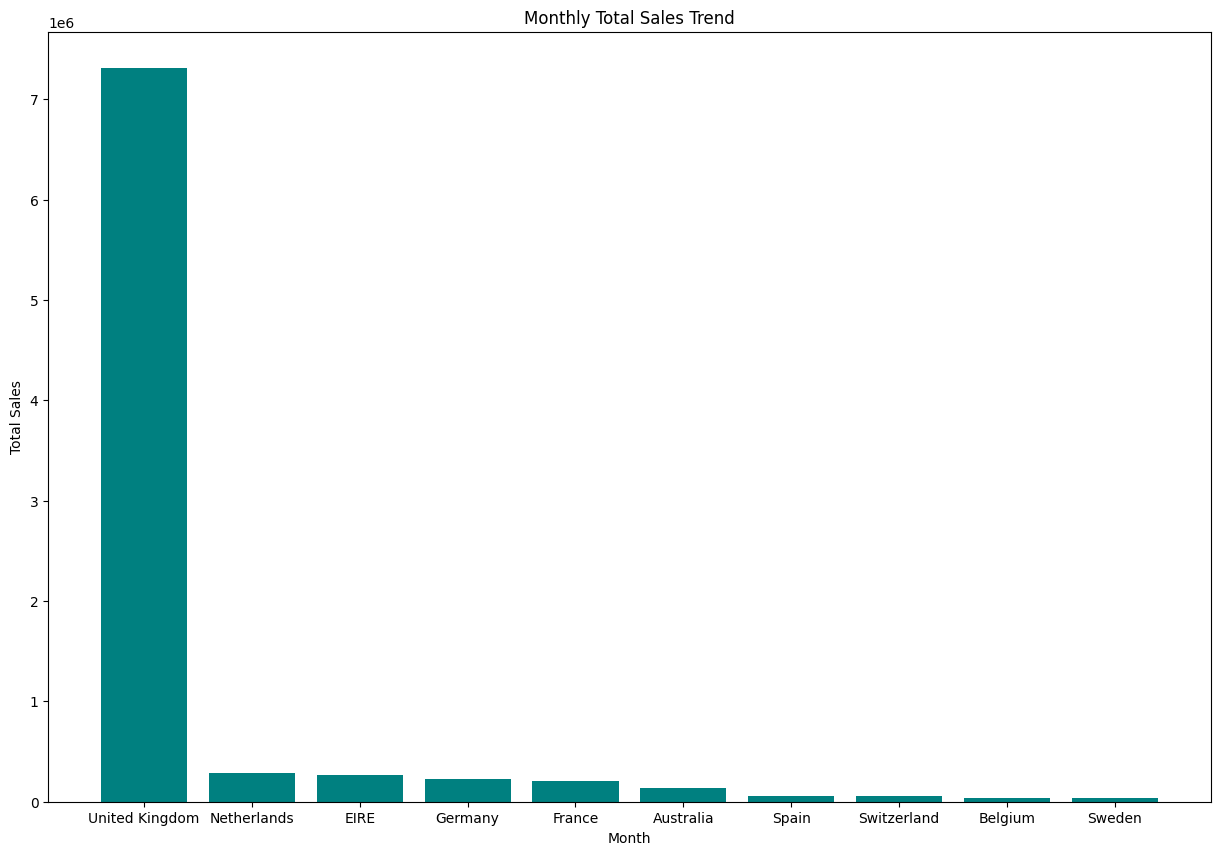

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
plt.bar(top_county['Country'].head(10), top_county['Total_price'].head(10), color='teal')
plt.title('Monthly Total Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)


### Analysing to know top customrs by revenue their countries

In [58]:

df1.groupby(['CustomerID',"Country"]).agg({'InvoiceNo':"nunique",
                              "Total_price":"sum"}).reset_index().sort_values(by="Total_price",ascending=False).head()

,CustomerID,Country,InvoiceNo,Total_price
1698,14646.0,Netherlands,74,280206.02
4210,18102.0,United Kingdom,60,259657.30
3737,17450.0,United Kingdom,46,194550.79
3017,16446.0,United Kingdom,2,168472.50
1888,14911.0,EIRE,201,143825.06


## Final Advice to maintain or improve sales from different countries
* Since there are no much sales in many countries,Partner with influencers(from those countries)  to promote brand trust
* Use native language and local slang in your emails or ads
* Automatically adjust currency, language, and shipping options based on the customer’s location
* Implement a loyalty or referral program (e.g., discounts for repeat purchases or referrals)

#  Average Basket Size (average number of products per transaction)
* calculating number of item bought(quantity) per transactions(per invoice)
* 

In [59]:
item_invoice=df1.groupby("InvoiceNo")["Quantity"].sum().reset_index()
item_invoice.sort_values(by="Quantity",ascending=False)

,InvoiceNo,Quantity
18503,581483,80995
1909,541431,74215
8112,556917,15049
10612,563076,14730
14371,572035,13392
...,...,...
1930,541505,1
3815,546328,1
10125,561895,1
3816,546329,1


In [60]:
Average_basket_size=item_invoice["Quantity"].mean()

In [61]:
Average_basket_size.round(3)

279.548

#### Checking for the number of invoices that has higher quantity 

In [62]:
high_baskets = item_invoice[item_invoice["Quantity"]>= Average_basket_size]
high_baskets.count() ## 4886 invoices are greater than the Average_basket_size

InvoiceNo    4886
Quantity     4886
dtype: int64

#### Checking for the number of invoices that has lower quantity 

In [66]:
low_baskets = item_invoice[item_invoice["Quantity"]<= Average_basket_size]
low_baskets.count() ## 13650 invoices are less than the Average_basket_size

InvoiceNo    13650
Quantity     13650
dtype: int64

## Strategies to Increase Basket Size
##### since there is a low quantity per transaction that means customers are buying only a few items per transaction
* Recommend related items(Example: "Customers who bought X also bought Y.")
* Offer product bundles at a slight discount to encourage bulk buying
* Improve Product Discovery: Make sure customers easily find related products

# Total sale over time (monthly and weekly)

In [67]:
df1["Month"]=df1["InvoiceDate"].dt.month_name()
df1["Day"]=df1["InvoiceDate"].dt.day
df1["Year"]=df1["InvoiceDate"].dt.year

In [68]:
sale_month=df1.groupby(['Month'])['Total_price'].sum().reset_index()
ordered_month=['January','February', 'March','April', 'May','June','July','August','September','October','November','December']
sale_month["Month"]=pd.Categorical(sale_month["Month"], categories=ordered_month, ordered=False)
sale_month.sort_values(by="Total_price",ascending=False)  

,Month,Total_price
9,November,1161817.380
2,December,1090906.680
10,October,1039318.790
11,September,952838.382
8,May,678594.560
6,June,661213.690
1,August,645343.900
5,July,600091.011
7,March,595500.760
4,January,569445.040


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

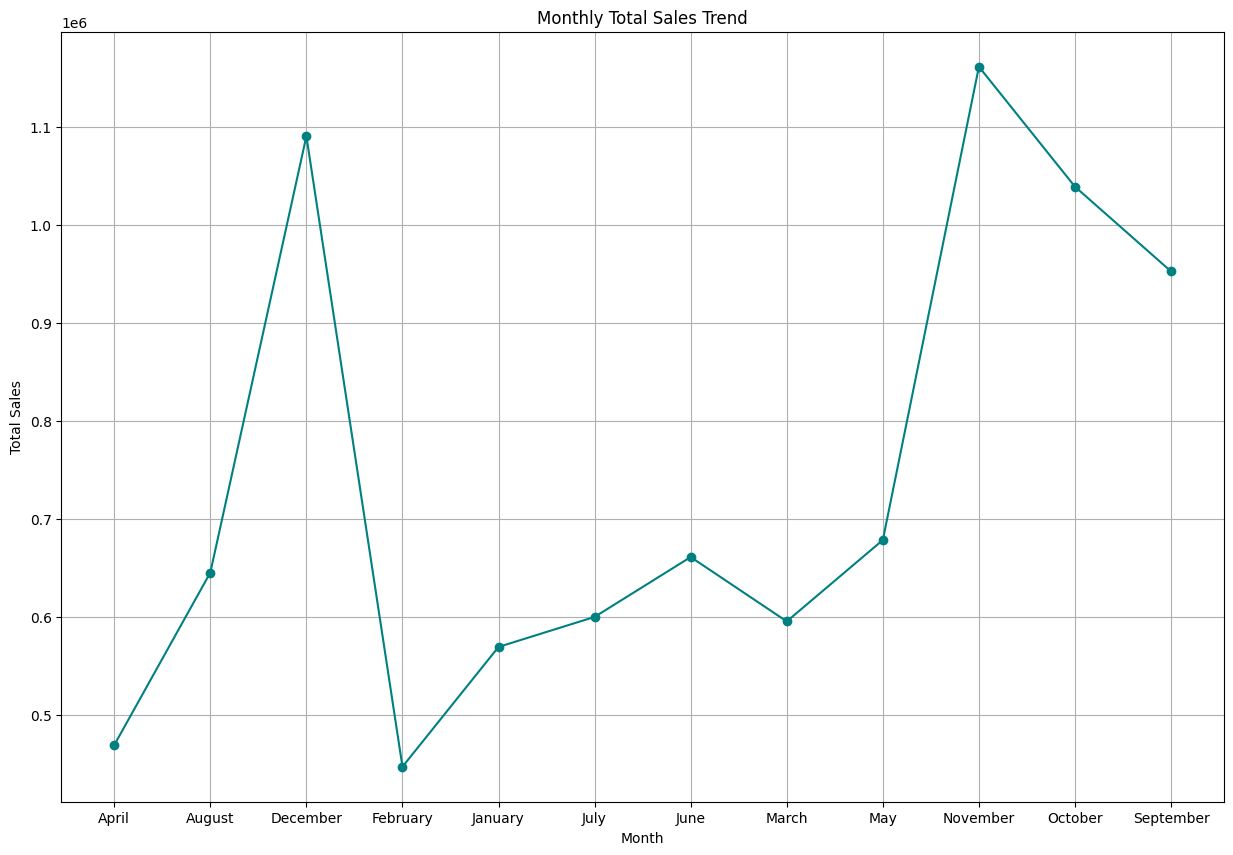

In [70]:
plt.figure(figsize=(15,10))
plt.plot(sale_month['Month'], sale_month['Total_price'], marker='o', color='teal')
plt.title('Monthly Total Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(True)

## For Weekly

In [71]:
df1["week"]=df1["InvoiceDate"].dt.isocalendar().week

In [72]:
df1.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,Bin_unitprice,Month,Day,Year,week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,medium,December,1,2010,48
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high,December,1,2010,48


In [73]:
weeklly_trend=df1.groupby("week")["Total_price"].sum().reset_index()
weeklly_trend.sort_values(by="Total_price",ascending=False).head()

,week,Total_price
48,49,622016.870
47,48,401174.550
37,38,309569.211
39,40,297116.860
45,46,277773.940


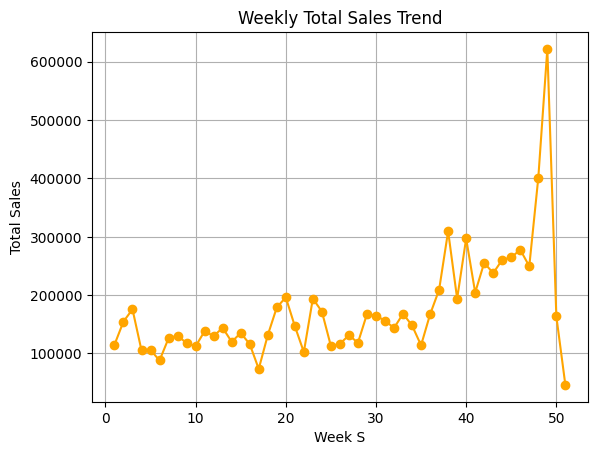

In [74]:
plt.plot(weeklly_trend['week'], weeklly_trend['Total_price'], marker='o', color='orange')
plt.title('Weekly Total Sales Trend')
plt.xlabel('Week S')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.grid(True)

### monthly and weekly trend together

In [75]:
weeklly_trend=df1.groupby(["Month","week"])["Total_price"].sum().reset_index()
weeklly_trend.sort_values(by="Total_price",ascending=False).head()

,Month,week,Total_price
11,December,49,622016.870
59,September,38,309569.211
51,October,40,297116.860
47,November,46,277773.940
46,November,45,264765.980


In [76]:
df1.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,Bin_unitprice,Month,Day,Year,week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,medium,December,1,2010,48
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high,December,1,2010,48


# Time-based purchasing patterns .

In [77]:
## Extracting hour and day 
df1["Hour"]=df["InvoiceDate"].dt.hour
df1["Day"]=df["InvoiceDate"].dt.day_name()
df1.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_price,Bin_unitprice,Month,Day,Year,week,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,medium,December,Wednesday,2010,48,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,high,December,Wednesday,2010,48,8


## For hour (showing how many transactions occur each hour)

In [81]:
hour_transa =df1.groupby("Hour").agg({"InvoiceNo":"nunique","Total_price":"sum"}).reset_index()
hour_transa.columns=["Hour","No_of_trascation_hour","Total_price"]
hour_transa.sort_values(by="Total_price",ascending=True)   ## no of invoices(transaction) made per hour

## From the analysis products are mostly sold arround 9am to 4pm

,Hour,No_of_trascation_hour,Total_price
0,6,1,4.250
14,20,18,18932.760
1,7,29,31059.210
13,19,144,49028.460
12,18,169,104954.430
11,17,544,234413.521
2,8,555,282115.630
10,16,1100,468885.800
3,9,1394,842605.171
9,15,2038,966191.750


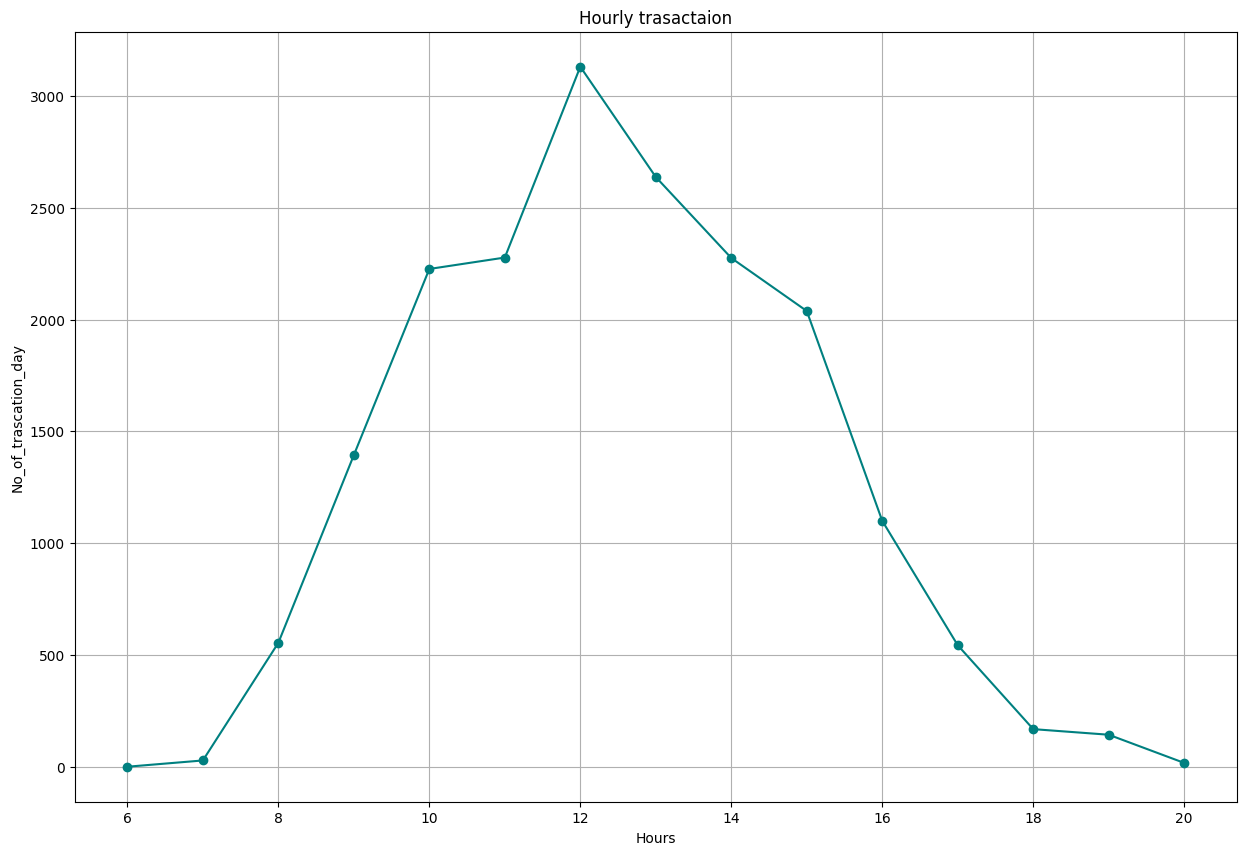

In [83]:
plt.figure(figsize=(15,10))
plt.plot(hour_transa['Hour'], hour_transa['No_of_trascation_hour'], marker='o', color='teal')
plt.title('Hourly trasactaion')
plt.xlabel('Hours')
plt.ylabel('No_of_trascation_day')
plt.xticks(rotation=0)
plt.grid(True)

###  For Days(showing how many trascation are made daily and the day with the most revenued )


In [84]:
day_transa =df1.groupby("Day").agg({"InvoiceNo":"nunique","Total_price":"sum"}).reset_index()
day_transa.columns=["Day","No_of_trascation_day",'Total_price']
day_transa.sort_values(by="Total_price",ascending=True) ##no of invoices(transaction) made per day

## From the analysis products are always down on sundays  

,Day,No_of_trascation_day,Total_price
2,Sunday,2169,792514.221
1,Monday,2863,1367146.411
0,Friday,2831,1485917.401
5,Wednesday,3455,1588336.170
4,Tuesday,3185,1700634.631
3,Thursday,4033,1976859.070


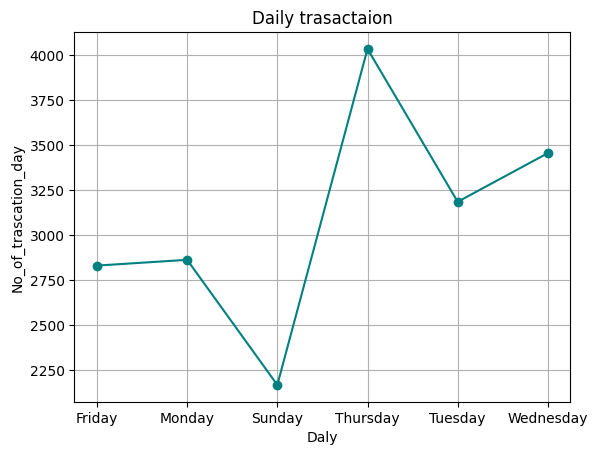

In [85]:
plt.plot(day_transa['Day'], day_transa['No_of_trascation_day'], marker='o', color='teal')
plt.title('Daily trasactaion')
plt.xlabel('Daly')
plt.ylabel('No_of_trascation_day')
plt.xticks(rotation=0)
plt.grid(True)